<a href="https://colab.research.google.com/github/samrat-rm/Brain-Cache/blob/main/LinRegMay26_Session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 118MB/s]


In [63]:
df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [64]:
df.shape

(19820, 18)

In [65]:
df['make'].nunique(), df['model'].nunique()

(41, 3233)

In [66]:
# label encoding
df['make'] = df.groupby('make')['selling_price'].transform('mean')
df['model'] = df.groupby('model')['selling_price'].transform('mean')

In [67]:
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


In [68]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_new = scaler.fit_transform(X_train)
display(type(X_new)) #its a numpy arr, we need Pandas arr
X_train = pd.DataFrame(X_new, columns = X_train.columns)

numpy.ndarray

`fit_transform(data)`:

`fit`: This step calculates the mean and standard deviation for each feature in the provided data. It 'learns' these parameters from the input data.

`transform`: After learning the parameters, this step applies the scaling (subtracts the mean and divides by the standard deviation) to the same data.

When to use it: You use `fit_transform` on your training data (X_train) because you want your model to learn the scaling parameters only from the training set. This prevents data leakage from the test set into the training process.

Since the `fit_transform` already recorded the meana and SD data for `fit` We can directly do `transform` for test data and this way the data is also not leaked.

In [71]:
X_new = scaler.transform(X_test) # only transform. no fit_transform
X_test = pd.DataFrame(X_new, columns = X_test.columns)

### Training a model using only one feature

In [72]:
X1_train = X_train[['model']]
X1_test = X_test[['model']]

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X1_train, y_train) # learns the parameters.

LinearRegression()

In [74]:
# y = w*x + w0
print(model.coef_, model.intercept_)

[4.67289908] 6.578468924697273


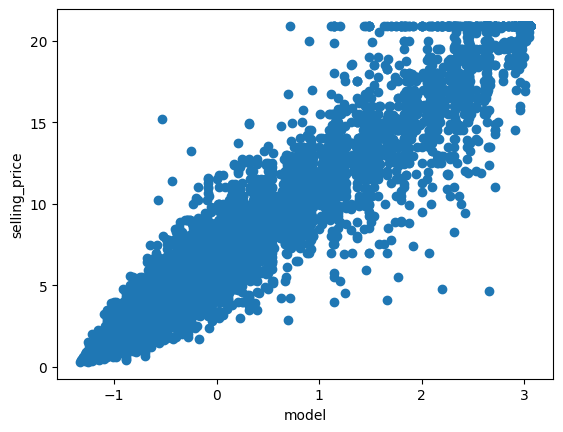

In [75]:
plt.scatter(X1_train, y_train)
plt.xlabel('model')
plt.ylabel('selling_price')
plt.show();

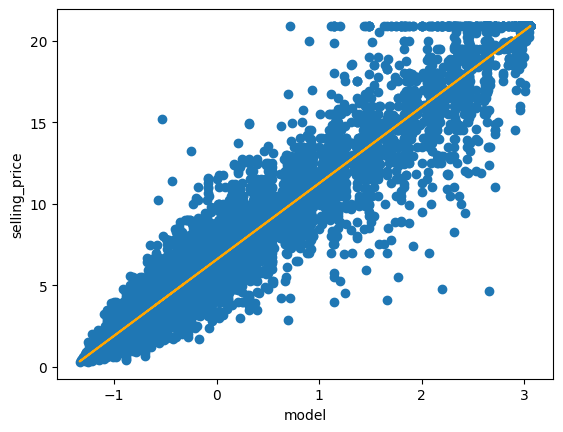

In [76]:
plt.scatter(X1_train, y_train)
plt.plot(X1_train, model.predict(X1_train), color='orange')
plt.xlabel('model')
plt.ylabel('selling_price')
plt.show();

In [77]:
y_pred = model.predict(X1_test)
y_pred[:10]

array([ 4.44371573,  5.03189066,  5.61257064,  5.75414187,  2.24501683,
       11.41615833,  2.31729205,  4.24266079,  5.62397599,  1.13683782])

In [78]:
y_test[:10]

,selling_price
960,7.00
4073,4.75
4339,6.30
19325,5.25
438,2.10
13078,12.00
5760,2.48
9792,3.50
3585,5.00
1147,1.25


In [79]:
# Rsquare
model.score(X1_test, y_test)

0.940979262430343

# Multivariate Linear Regression

In [81]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train, y_train) # learns the parameters.
# X_train included the model data

LinearRegression()

In [82]:
# y = w1.x1 + w2.x2 + ....

print(model2.coef_)
print(model2.intercept_)

[ 0.27813197 -0.14013565 -0.18590768  0.13924039  0.04679916 -0.27813197
  0.24605178  4.02063257 -0.05837169 -0.01638025  0.06013809  0.04818182
  0.01863947 -0.10007882 -0.03729704 -0.09549806 -0.15212018]
6.5784689246972645


In [83]:
weights=model2.coef_

In [84]:
X_train.shape

(15856, 17)

In [85]:
y_pred = model2.predict(X_test)
y_pred[:10]

array([ 4.9405943 ,  5.41944515,  5.79134646,  6.00483191,  1.8135126 ,
       11.784341  ,  2.07682075,  4.16500267,  5.21875115,  0.27207412])

In [117]:
model2.score(X_test,y_test)

0.9466197443095883

In [87]:
X_train.head()

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-0.489414,0.502456,0.243228,0.240112,0.120997,0.489414,-0.284819,-0.599662,1.251112,-0.099681,1.015253,-0.019456,-0.056244,-0.974099,0.496825,0.443384,-0.423776
1,-1.429050,0.900732,-0.799809,1.011304,1.854161,1.429050,2.975929,0.929139,-0.799289,-0.099681,1.015253,-0.019456,-0.056244,-0.974099,-2.012782,0.443384,-0.423776
2,1.076647,0.366270,1.841617,-0.439780,-0.541816,-1.076647,-0.521072,0.064971,1.251112,-0.099681,1.015253,-0.019456,-0.056244,-0.974099,0.496825,0.443384,-0.423776
3,1.389859,-0.972890,1.013255,-0.534965,-0.317892,-1.389859,-0.604885,-0.206702,1.251112,-0.099681,-0.984977,-0.019456,-0.056244,1.026590,0.496825,0.443384,-0.423776
4,-2.055474,1.183386,-1.399497,0.630564,0.712154,2.055474,-0.163433,-0.799491,1.251112,-0.099681,-0.984977,-0.019456,-0.056244,1.026590,0.496825,0.443384,-0.423776


In [88]:
imp = pd.DataFrame(list(zip(X_train.columns,np.abs(model2.coef_))),
                   columns=['feature', 'coeff'])

In [89]:
imp

,feature,coeff
0,year,0.278132
1,km_driven,0.140136
2,mileage,0.185908
3,engine,0.139240
4,max_power,0.046799
5,age,0.278132
6,make,0.246052
7,model,4.020633
8,Individual,0.058372
9,Trustmark Dealer,0.016380


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'year'),
  Text(1, 0, 'km_driven'),
  Text(2, 0, 'mileage'),
  Text(3, 0, 'engine'),
  Text(4, 0, 'max_power'),
  Text(5, 0, 'age'),
  Text(6, 0, 'make'),
  Text(7, 0, 'model'),
  Text(8, 0, 'Individual'),
  Text(9, 0, 'Trustmark Dealer'),
  Text(10, 0, 'Diesel'),
  Text(11, 0, 'Electric'),
  Text(12, 0, 'LPG'),
  Text(13, 0, 'Petrol'),
  Text(14, 0, 'Manual'),
  Text(15, 0, '5'),
  Text(16, 0, '>5')])

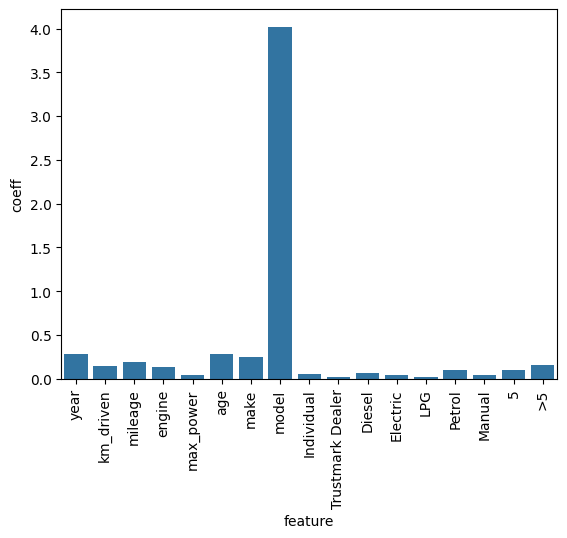

In [90]:
sns.barplot(x='feature', y='coeff', data=imp)
plt.xticks(rotation=90)

## Linear Regression Scratch Code

In [122]:
X.head()

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,2012.0,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,2016.0,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2010.0,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2012.0,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,2015.0,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


$$\hat{y}_i = W^T x_i$$

In [91]:
def predict(X,weights):
  return np.dot(X,weights)



$$L(W) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [118]:
def loss(X,Y,weights):
  Y_HAT=predict(X,weights)
  error=np.mean((Y-Y_HAT)**2)
  return error

Let's derive the formula for the gradient of the Mean Squared Error (MSE) loss function with respect to the weight vector $W$.

The MSE loss function for $n$ samples is:
$$L(W) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Where:
*   $y_i$ is the actual target value for the $i$-th data point.
*   $\hat{y}_i$ is the predicted value for the $i$-th data point.

In linear regression, the predicted value $\hat{y}_i$ for a given input feature vector $x_i$ and weight vector $W$ is:
$$\hat{y}_i = W^T x_i$$
Substituting this into the MSE formula:
$$L(W) = \frac{1}{n} \sum_{i=1}^{n} (y_i - W^T x_i)^2$$

To find the gradient of $L(W)$ with respect to $W$, we use the chain rule. Let $u_i = (y_i - W^T x_i)$. Then, the term inside the summation becomes $u_i^2$.

First, the derivative of $(u_i)^2$ with respect to $u_i$:
$$\frac{\partial}{\partial u_i} (u_i^2) = 2u_i$$

Next, the derivative of $u_i$ with respect to $W$:
$$\frac{\partial u_i}{\partial W} = \frac{\partial}{\partial W} (y_i - W^T x_i)$$
Since $y_i$ is a constant with respect to $W$, its derivative is 0.
The derivative of $W^T x_i$ with respect to $W$ is $x_i$.
Therefore,
$$\frac{\partial u_i}{\partial W} = -x_i$$

Applying the chain rule to the individual term $(y_i - W^T x_i)^2$:
$$\frac{\partial}{\partial W} (y_i - W^T x_i)^2 = \left( \frac{\partial}{\partial u_i} (u_i^2) \right) \left( \frac{\partial u_i}{\partial W} \right)$$
$$\frac{\partial}{\partial W} (y_i - W^T x_i)^2 = 2(y_i - W^T x_i) (-x_i) = -2x_i (y_i - W^T x_i)$$

Now, applying this back to the full loss function, taking the derivative inside the summation:
$$\nabla L(W) = \frac{1}{n} \sum_{i=1}^{n} -2x_i (y_i - W^T x_i)$$
$$\nabla L(W) = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i)$$

To express this in matrix form, let $X$ be the design matrix (where each row is $x_i^T$), $Y$ be the column vector of actual values, and $\hat{Y}$ be the column vector of predicted values. Then, $\hat{Y} = XW$.

The summation $\sum_{i=1}^{n} x_i (y_i - \hat{y}_i)$ can be written in matrix form as $X^T (Y - \hat{Y})$.
Therefore, the final gradient in matrix form is:
$$\nabla L(W) = -\frac{2}{n} X^T (Y - \hat{Y})$$
Or, by negating the term inside the parenthesis:
$$\nabla L(W) = \frac{2}{n} X^T (\hat{Y} - Y)$$
This is the formula used in the `gradients` function.

In [103]:
def gradients(X,Y,weights):
  Y_HAT=predict(X,weights)

  grads=2*np.dot(X.T,Y_HAT-Y)/len(Y)
  return grads

In [104]:
def gradient_descent(X,Y,learning_rate=0.1,n_iterations=300):
  n,d=X.shape

  #step 1
  W=np.random.rand(d) #initializing random weights

  error_list=[]

  for _ in range(n_iterations):
    #step 2
    e=loss(X,Y,W)
    error_list.append(e)

    dW=gradients(X,Y,W)

    #step 3
    W=W-learning_rate*dW
  return W,error_list


The scratch code implements Linear Regression using Gradient Descent. Here's a breakdown of the key functions:

*   **`predict(X, weights)`**: This function calculates the predicted `Y_HAT` values by performing a dot product of the input features `X` and the current `weights`. This is the core prediction step in linear regression.

*   **`loss(X, Y, weights)`**: This function computes the Mean Squared Error (MSE) between the actual `Y` values and the predicted `Y_HAT` values. MSE is a common loss function for regression problems, measuring the average squared difference between actual and predicted values.

*   **`gradients(X, Y, weights)`**: This function calculates the gradients of the loss function with respect to the weights. These gradients indicate the direction and magnitude by which the weights need to be adjusted to minimize the loss. In linear regression, the gradient is proportional to the dot product of the transpose of `X` and the difference between `Y_HAT` and `Y`.

*   **`gradient_descent(X, Y, learning_rate, n_iterations)`**: This is the main optimization algorithm. It iteratively updates the `weights` to minimize the `loss` function:
    1.  It initializes `weights` randomly.
    2.  In each iteration, it calculates the current `loss` and the `gradients`.
    3.  It updates the `weights` by subtracting the `learning_rate` multiplied by the `gradients`. The `learning_rate` controls the step size of each update.
    4.  It stores the `loss` at each iteration to track the optimization progress.

*   **`r2_score(y_true, y_pred)`**: This function calculates the R-squared (coefficient of determination) score, which is a measure of how well the model's predictions explain the variability of the dependent variable. A higher R-squared value indicates a better fit.

In [105]:
W_best,errors=gradient_descent(X_train,y_train)

In [106]:
W_best

array([ 0.40649679, -0.14054514, -0.1701872 ,  0.13505323,  0.05582472,
       -0.14541528,  0.25239037,  4.01555026, -0.05991497, -0.01535698,
        0.1706128 ,  0.04899556,  0.03208823,  0.01757599, -0.03856722,
       -0.02833237, -0.0749948 ])

In [ ]:

errors

In [ ]:
len(W_best)

In [ ]:
weights

In [ ]:
y_train_pred=predict(X_train,W_best)
y_train_pred[:10]

In [ ]:

def r2_score(y_true,y_pred):
  numerator=np.sum((y_true-y_pred)**2)
  denominator=np.sum((y_true-y_true.mean())**2)
  score=1-(numerator/denominator)
  return score

In [ ]:
r2_score(y_train,y_train_pred)

In [ ]:
plt.plot(errors)

In [ ]:
r2_score(y_test,y_pred)

In [ ]:
r2_score

In [ ]:
#Incorporating W0

In [ ]:
X_train.head()

In [ ]:
x0=pd.DataFrame([1]*len(X_train),columns=['x0'])
x0.head()

In [ ]:
X_train_new = pd.concat([x0, X_train], axis=1)
X_train_new.head()

In [ ]:
W_best,error_list=gradient_descent(X_train_new, y_train)

In [31]:
W_best

NameError: name 'W_best' is not defined

In [ ]:
model.intercept_


In [ ]:
error_list

In [ ]:
plt.plot(error_list)

In [ ]:
y_train_pred = predict(X_train_new, W_best)
y_train_pred[:10]

In [ ]:
r2_score(y_train, y_train_pred)

In [ ]:
# model.score(y_test,y_pred)

In [32]:
X=df.drop('selling_price', axis=1)
y=df[['selling_price']]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

y_train = np.array(y_train)

In [34]:
import statsmodels.api as sm

In [35]:
X_sm=sm.add_constant(X_train)
X_sm.head()

,const,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
3443,1.0,2013.0,67000,15.60,1497.0,116.30,10.0,5.979902,4.364286,0,0,0,0,0,1,0,1,0
16090,1.0,2017.0,35000,20.51,998.0,67.04,6.0,4.684721,3.808235,1,0,0,0,0,1,1,1,0
11070,1.0,2016.0,130000,21.58,1248.0,88.70,7.0,4.381194,4.450000,1,0,1,0,0,0,0,1,0
19214,1.0,2018.0,43266,18.16,1196.0,86.80,5.0,5.858258,5.105000,0,0,0,0,0,1,1,1,0
17843,1.0,2011.0,48000,16.20,1493.0,110.00,12.0,5.458819,3.250000,1,0,1,0,0,0,1,1,0


In [36]:
model=sm.OLS(y_train,X_sm)
results=model.fit()

In [37]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:56:52   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -8.84e-05    1.9e-06  

In [38]:
#Assumptions -

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:

vif = pd.DataFrame()
X_t = pd.DataFrame(X_train, columns=X_train.columns)
X_t

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
3443,2013.0,67000,15.60,1497.0,116.30,10.0,5.979902,4.364286,0,0,0,0,0,1,0,1,0
16090,2017.0,35000,20.51,998.0,67.04,6.0,4.684721,3.808235,1,0,0,0,0,1,1,1,0
11070,2016.0,130000,21.58,1248.0,88.70,7.0,4.381194,4.450000,1,0,1,0,0,0,0,1,0
19214,2018.0,43266,18.16,1196.0,86.80,5.0,5.858258,5.105000,0,0,0,0,0,1,1,1,0
17843,2011.0,48000,16.20,1493.0,110.00,12.0,5.458819,3.250000,1,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,2019.0,29250,13.68,2393.0,147.80,4.0,10.532763,18.074000,0,0,1,0,0,0,1,0,1
18898,2018.0,18600,22.00,1197.0,81.80,5.0,4.684721,4.251579,1,0,0,0,0,1,1,1,0
11798,2016.0,42530,15.29,1591.0,121.30,7.0,5.458819,8.605000,0,0,0,0,0,1,1,1,0
6637,2013.0,15000,18.88,1995.0,184.00,10.0,17.349017,18.395109,0,0,1,0,0,0,0,1,0


In [41]:
X_t.shape

(15856, 17)

In [42]:
X_t.shape[1]

17

In [43]:
vif = pd.DataFrame()
X_t = pd.DataFrame(X_train, columns=X_train.columns)
vif['Features'] = X_t.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,year,395.89
13,Petrol,18.29
10,Diesel,17.29
5,age,15.03
16,>5,13.04
15,5,11.75
3,engine,6.30
7,model,6.16
4,max_power,5.02
6,make,3.33


In [44]:
cols2=vif['Features'][1:]
X2 = pd.DataFrame(X_t, columns=X_train.columns)[cols2]
X2.head()

,Petrol,Diesel,age,>5,5,engine,model,max_power,make,mileage,Manual,LPG,Electric,km_driven,Individual,Trustmark Dealer
3443,1,0,10.0,0,1,1497.0,4.364286,116.30,5.979902,15.60,0,0,0,67000,0,0
16090,1,0,6.0,0,1,998.0,3.808235,67.04,4.684721,20.51,1,0,0,35000,1,0
11070,0,1,7.0,0,1,1248.0,4.450000,88.70,4.381194,21.58,0,0,0,130000,1,0
19214,1,0,5.0,0,1,1196.0,5.105000,86.80,5.858258,18.16,1,0,0,43266,0,0
17843,0,1,12.0,0,1,1493.0,3.250000,110.00,5.458819,16.20,1,0,0,48000,1,0


In [45]:
X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
sm_model = sm.OLS(list(y_train), X2_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:56:53   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.9505      0.180  

In [46]:
vif = pd.DataFrame()
X_t = pd.DataFrame(X_train[cols2], columns=cols2)
vif['Features'] = X_t.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,5,51.79
5,engine,50.07
9,mileage,29.88
1,Diesel,29.25
7,max_power,29.03
0,Petrol,24.59
6,model,17.83
8,make,14.24
2,age,12.94
3,>5,11.17


In [47]:
X_t.drop(columns=['5'],inplace=True)

In [48]:
X_t.head()

Features,Petrol,Diesel,age,>5,engine,model,max_power,make,mileage,Manual,LPG,Electric,km_driven,Individual,Trustmark Dealer
3443,1,0,10.0,0,1497.0,4.364286,116.30,5.979902,15.60,0,0,0,67000,0,0
16090,1,0,6.0,0,998.0,3.808235,67.04,4.684721,20.51,1,0,0,35000,1,0
11070,0,1,7.0,0,1248.0,4.450000,88.70,4.381194,21.58,0,0,0,130000,1,0
19214,1,0,5.0,0,1196.0,5.105000,86.80,5.858258,18.16,1,0,0,43266,0,0
17843,0,1,12.0,0,1493.0,3.250000,110.00,5.458819,16.20,1,0,0,48000,1,0


In [49]:
vif = pd.DataFrame()

vif['Features'] = X_t.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,engine,47.75
6,max_power,28.80
1,Diesel,26.08
8,mileage,22.07
0,Petrol,19.62
5,model,17.61
7,make,14.23
2,age,12.70
9,Manual,8.65
12,km_driven,2.60


In [50]:
X_t.drop(columns=['engine'], inplace=True)

In [51]:
vif = pd.DataFrame()

vif['Features'] = X_t.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,Diesel,23.39
7,mileage,21.55
5,max_power,18.36
0,Petrol,18.33
4,model,17.44
6,make,14.06
2,age,11.96
8,Manual,8.47
11,km_driven,2.57
12,Individual,1.78


In [52]:
X_t.drop(columns=['Diesel'], inplace=True)

In [53]:
vif = pd.DataFrame()

vif['Features'] = X_t.columns
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,max_power,17.68
3,model,16.74
5,make,14.05
6,mileage,13.27
1,age,10.56
7,Manual,8.14
10,km_driven,2.56
0,Petrol,2.17
11,Individual,1.76
2,>5,1.64


In [54]:
model = LinearRegression()
model.fit(X_t, y_train)

model.score(X_t, y_train)

0.9448675810554413

In [55]:
y_hat=model.predict(X_t)

In [56]:
y_hat

array([[ 4.56818469],
       [ 4.13460118],
       [ 4.78319896],
       ...,
       [ 8.69845619],
       [17.90553213],
       [ 6.24578916]])

In [57]:
errors=y_train-y_hat
errors[:10]

array([[ 0.18181531],
       [-0.13460118],
       [-0.43319896],
       [ 0.38043257],
       [-0.04845661],
       [-0.59024458],
       [ 2.22148883],
       [ 1.6655996 ],
       [-0.47530669],
       [-0.61766083]])

<Axes: ylabel='Count'>

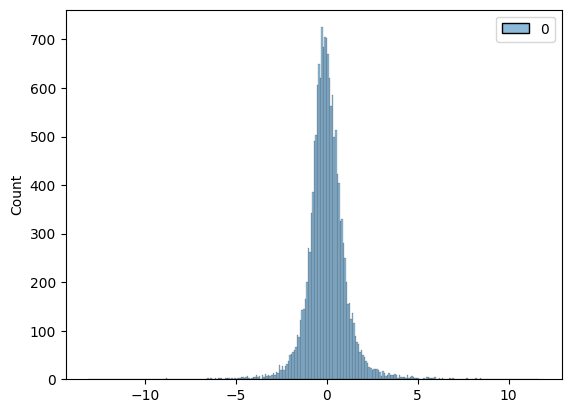

In [58]:
import seaborn as sns
sns.histplot(errors)

In [59]:
from scipy import stats
res=stats.shapiro(errors)
res.statistic

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15856.
  res = hypotest_fun_out(*samples, **kwds)


np.float64(0.8900542035040424)

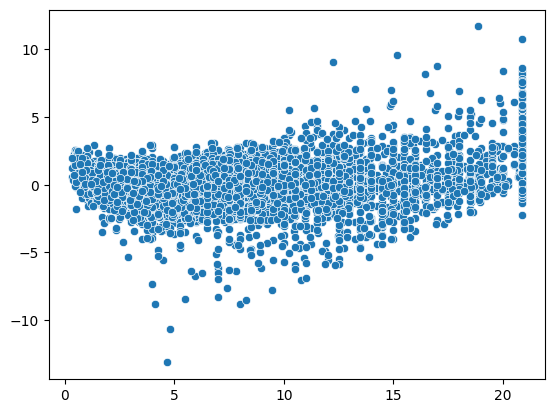

In [60]:
sns.scatterplot(x = y_train.reshape(-1,), y = errors.reshape(-1,));
